In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint

# Params
DATA_PATH = "../data/dataset_G21.csv"
ANCHOR = "OJ=F"

# Load data (multi-index)
df_raw = pd.read_csv(DATA_PATH, header=[0, 1], index_col=0, parse_dates=True)
df_prices = df_raw.xs('Adj Close', axis=1, level=0).ffill().dropna(axis=1, how='all').dropna()

# Log-prices for OLS
log_prices = np.log(df_prices)

# Universe (excluding anchor)
universe = [col for col in df_prices.columns if col != ANCHOR]

print(f"Dataset size: {len(df_prices)} days")

Dataset size: 2083 days


In [2]:
# Train/Test split (70/30)
split_idx = int(len(log_prices) * 0.7)
train_log = log_prices.iloc[:split_idx]

# Engle-Granger test on the universe
p_values = {}
for stock in universe:
    _, p_val, _ = coint(train_log[ANCHOR], train_log[stock])
    p_values[stock] = p_val

# Keep the lowest p-value
best_stock = min(p_values, key=p_values.get)
print(f"Selected pair: {ANCHOR} & {best_stock} (p-val: {p_values[best_stock]:.4f})")

# OLS to get alpha and beta
X = sm.add_constant(train_log[best_stock])
model = sm.OLS(train_log[ANCHOR], X).fit()

alpha = model.params['const']
beta = model.params[best_stock]

print(f"Beta: {beta:.4f} | Alpha: {alpha:.4f}")

Selected pair: OJ=F & CC=F (p-val: 0.5312)
Beta: 1.1379 | Alpha: -3.9486


In [3]:
# Strategy parameters
W = 60
sigma_open = 2.0
sigma_close = 0.5

# Spread and rolling Z-score
spread = log_prices[ANCHOR] - beta * log_prices[best_stock] - alpha
rolling_mean = spread.rolling(window=W).mean()
rolling_std = spread.rolling(window=W).std()
z_score = (spread - rolling_mean) / rolling_std

# Trading logic (State Machine)
signals = pd.Series(0, index=z_score.index, dtype=int)
current_pos = 0 

for i in range(W, len(z_score)):
    z = z_score.iloc[i]
    
    # Entry rules
    if z > sigma_open:
        current_pos = -1
    elif z < -sigma_open:
        current_pos = 1
    # Exit rules
    elif abs(z) < sigma_close:
        current_pos = 0
        
    signals.iloc[i] = current_pos

# Quick sanity check on signals
print("Signal distribution:")
print(signals.value_counts())

Signal distribution:
 0    1275
-1     418
 1     390
Name: count, dtype: int64


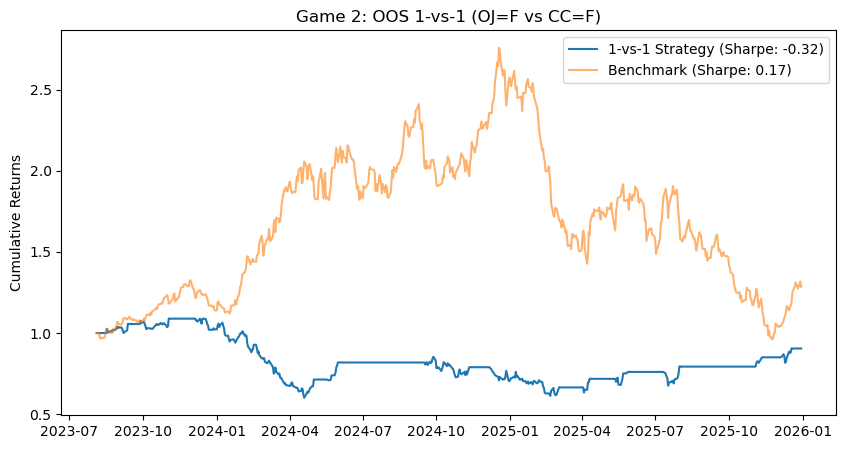

In [4]:
# OOS data
test_signals = signals.iloc[split_idx:].shift(1).fillna(0) # Shift to avoid look-ahead
test_prices_anchor = df_prices[ANCHOR].iloc[split_idx:]
test_prices_equity = df_prices[best_stock].iloc[split_idx:]

# Raw returns
ret_anchor = test_prices_anchor.pct_change().fillna(0)
ret_equity = test_prices_equity.pct_change().fillna(0)

# Gross strategy returns (normalized)
gross_exposure = 1 + abs(beta)
strat_rets_gross = test_signals * (ret_anchor - beta * ret_equity) / gross_exposure

# Net returns (10 bps fees on turnover)
turnover = test_signals.diff().abs().fillna(0)
fees = 0.0010
strat_rets_net = strat_rets_gross - (turnover * fees)

# Cumulative returns
cum_strat = (1 + strat_rets_net).cumprod()
bench_rets = (ret_anchor + ret_equity) / 2 # Equal-weight benchmark
cum_bench = (1 + bench_rets).cumprod()

# Annualized Sharpe (Rf = 4%)
def get_sharpe(r, cum):
    ann_ret = (cum.iloc[-1]) ** (252 / len(r)) - 1
    vol = r.std() * np.sqrt(252)
    return (ann_ret - 0.04) / vol if vol > 1e-6 else 0.0

# Plot
plt.figure(figsize=(10, 5))
plt.plot(cum_strat, label=f"1-vs-1 Strategy (Sharpe: {get_sharpe(strat_rets_net, cum_strat):.2f})")
plt.plot(cum_bench, label=f"Benchmark (Sharpe: {get_sharpe(bench_rets, cum_bench):.2f})", alpha=0.6)
plt.title(f"Game 2: OOS 1-vs-1 ({ANCHOR} vs {best_stock})")
plt.ylabel("Cumulative Returns")
plt.legend()
plt.show()